In [15]:
import pandas as pd
import os

In [29]:
# load result csv files from the result_data folder
results = pd.read_csv("../result_data/rnn_lstm_fusion_predictions.csv")


In [30]:
import numpy as np

# create new column: true_result, which shows whether HG or AG is greater
# thus: if HG > AG, true_result = 1
# if HG < AG, true_result = -1
# if HG == AG, true_result = 0
results['true_result'] = results.apply(lambda row: 1 if row['HG'] > row['AG'] else (-1 if row['HG'] < row['AG'] else 0), axis=1)

# create new column: predicted_result, which shows whether lambda_home or lambda_away is greater
# thus: if lambda_home > lambda_away, predicted_result = 1
# if lambda_home < lambda_away, predicted_result = -1
# draw is declared, if the difference between lambda_home and lambda_away is less than xx

# escaping the draw trap:
# set t such that the accuracy of the model is maximized. This is done by iterating over a range of t values and calculating the accuracy for each t value. The t value that gives the highest accuracy is chosen as the threshold for declaring a draw.
# the range of t values is from 0 to 1, with a step size of 0.01. The accuracy is calculated as the number of correct predictions divided by the total number of predictions. The correct predictions are those where the predicted_result matches the true_result, or where the predicted_result is 0 (draw) and the true_result is also 0 (draw). The total number of predictions is the number of rows in the results dataframe. The accuracy is calculated for each t value, and the t value that gives the highest accuracy is chosen as the threshold for declaring a draw.

# calculate new columns for the home_predicted_abs_goals and away_predicted_abs_goals
# round up the higher lambda and round down the lower lambda
results['home_predicted_abs_goals'] = results.apply(lambda row: int(np.ceil(row['lambda_home'])) if row['lambda_home'] > row['lambda_away'] else int(np.floor(row['lambda_home'])), axis=1)
results['away_predicted_abs_goals'] = results.apply(lambda row: int(np.ceil(row['lambda_away'])) if row['lambda_away'] > row['lambda_home'] else int(np.floor(row['lambda_away'])), axis=1)


In [31]:
# calculate accuracy of the predictions
accuracy = (results['true_result'] == results['outcome_decision']).mean()
print(accuracy)

# confusion matrix
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(results['true_result'], results['outcome_decision'], labels=[1, 0, -1])
print(conf_matrix)

0.5
[[386  68 167]
 [158  65 147]
 [115  56 260]]


In [32]:
results

,game_id,HG,AG,lambda_home,lambda_away,expected_goal_diff,outcome_decision,true_result,home_predicted_abs_goals,away_predicted_abs_goals
0,20250815_GIR_RAY,1.0,3.0,1.503263,1.289067,0.214196,0,-1,2,1
1,20250815_LIV_BOU,4.0,2.0,2.172652,0.778841,1.393811,1,1,3,0
2,20250815_REN_OM,1.0,0.0,1.189906,1.506167,-0.316262,-1,1,1,2
3,20250816_ALA_LEV,2.0,1.0,1.546033,1.233629,0.312404,0,1,2,1
4,20250816_AVL_NEW,0.0,0.0,1.572681,1.189562,0.383119,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...
1417,20260504_CHE_NFO,1.0,3.0,2.029938,0.894625,1.135313,1,-1,3,0
1418,20260504_CRE_LAZ,1.0,2.0,1.084561,1.617207,-0.532646,-1,-1,1,2
1419,20260504_EVE_MCI,3.0,3.0,0.971743,1.770826,-0.799084,-1,0,0,2
1420,20260504_ROM_FIO,4.0,0.0,1.994318,0.892062,1.102256,1,1,2,0


[[386  68 167]
 [158  65 147]
 [115  56 260]]
Total true home wins: 621
Total true draws: 370
Total true away wins: 431


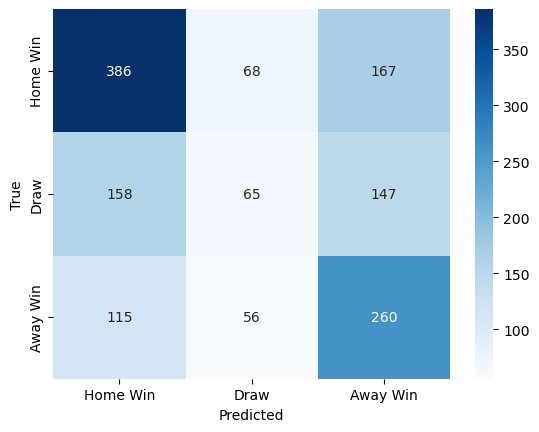

In [33]:
# create confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(results['true_result'], results['outcome_decision'], labels=[1, 0, -1])
print(confusion_matrix(results['true_result'], results['outcome_decision'], labels=[1, 0, -1]))
# display better readable confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(results['true_result'], results['outcome_decision'], labels=[1, 0, -1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Home Win', 'Draw', 'Away Win'], yticklabels=['Home Win', 'Draw', 'Away Win'])
plt.xlabel('Predicted')
plt.ylabel('True')

# compute total number of true home wins, draws, and away wins
true_home_wins = (results['true_result'] == 1).sum()
true_draws = (results['true_result'] == 0).sum()
true_away_wins = (results['true_result'] == -1).sum()

print(f"Total true home wins: {true_home_wins}")
print(f"Total true draws: {true_draws}")
print(f"Total true away wins: {true_away_wins}")


In [34]:
# calculate MAE and MSE for the predicted lambdas
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_home = mean_absolute_error(results['HG'], results['home_predicted_abs_goals'])
mae_away = mean_absolute_error(results['AG'], results['away_predicted_abs_goals'])
mse_home = mean_squared_error(results['HG'], results['home_predicted_abs_goals'])
mse_away = mean_squared_error(results['AG'], results['away_predicted_abs_goals'])
print(f"MAE Home: {mae_home}, MAE Away: {mae_away}")
print(f"MSE Home: {mse_home}, MSE Away: {mse_away}")

MAE Home: 1.0147679324894514, MAE Away: 0.8917018284106891
MSE Home: 1.709563994374121, MSE Away: 1.4627285513361463


## Diagnostics by league and season

In [35]:
# Add league/season identifiers to results from game_id
from pathlib import Path
import sys
import pandas as pd

# Ensure project root is importable when running from notebooks/
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.game_id_context import infer_league_and_season

# Resolve context for each game_id and merge into results
context_df = results["game_id"].astype(str).apply(infer_league_and_season).apply(pd.Series)
results = results.drop(columns=["league", "season"], errors="ignore").merge(
    context_df[["game_id", "league", "season"]], on="game_id", how="left"
 )

# Quick check
results

,game_id,HG,AG,lambda_home,lambda_away,expected_goal_diff,outcome_decision,true_result,home_predicted_abs_goals,away_predicted_abs_goals,league,season
0,20250815_GIR_RAY,1.0,3.0,1.503263,1.289067,0.214196,0,-1,2,1,Spain La Liga,2025-2026
1,20250815_LIV_BOU,4.0,2.0,2.172652,0.778841,1.393811,1,1,3,0,England Premier League,2025-2026
2,20250815_REN_OM,1.0,0.0,1.189906,1.506167,-0.316262,-1,1,1,2,France Ligue 1,2025-2026
3,20250816_ALA_LEV,2.0,1.0,1.546033,1.233629,0.312404,0,1,2,1,Spain La Liga,2025-2026
4,20250816_AVL_NEW,0.0,0.0,1.572681,1.189562,0.383119,0,0,2,1,England Premier League,2025-2026
...,...,...,...,...,...,...,...,...,...,...,...,...
1417,20260504_CHE_NFO,1.0,3.0,2.029938,0.894625,1.135313,1,-1,3,0,England Premier League,2025-2026
1418,20260504_CRE_LAZ,1.0,2.0,1.084561,1.617207,-0.532646,-1,-1,1,2,Italy Serie A,2025-2026
1419,20260504_EVE_MCI,3.0,3.0,0.971743,1.770826,-0.799084,-1,0,0,2,England Premier League,2025-2026
1420,20260504_ROM_FIO,4.0,0.0,1.994318,0.892062,1.102256,1,1,2,0,Italy Serie A,2025-2026


In [36]:
# calculate accuracy by league (season is always the same, since we only have one season in the test set)
accuracy_by_league = results.groupby("league").apply(
    lambda x: (x['true_result'] == x['outcome_decision']).mean()
).reset_index(name="accuracy")

print(accuracy_by_league)

                   league  accuracy
0  England Premier League  0.469649
1          France Ligue 1  0.492188
2      Germany Bundesliga  0.560606
3           Italy Serie A  0.491749
4           Spain La Liga  0.493007


/var/folders/dd/nkyzffbd1gdfdc7t3v9nd1840000gn/T/ipykernel_49822/2060935666.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_by_league = results.groupby("league").apply(


In [38]:
# calculate accuracy for home wins, draws, and away wins separately
accuracy_home_wins = (results[results['true_result'] == 1]['true_result'] == results[results['true_result'] == 1]['outcome_decision']).mean()
accuracy_draws = (results[results['true_result'] == 0]['true_result'] == results[results['true_result'] == 0]['outcome_decision']).mean()
accuracy_away_wins = (results[results['true_result'] == -1]['true_result'] == results[results['true_result'] == -1]['outcome_decision']).mean()

print(f"Accuracy Home Wins: {accuracy_home_wins}")
print(f"Accuracy Draws: {accuracy_draws}")
print(f"Accuracy Away Wins: {accuracy_away_wins}")

Accuracy Home Wins: 0.6215780998389694
Accuracy Draws: 0.17567567567567569
Accuracy Away Wins: 0.6032482598607889


In [39]:
# average of HG and AG by league
average_goals_by_league = results.groupby("league").agg(
    average_HG=pd.NamedAgg(column="HG", aggfunc="mean"),
    average_AG=pd.NamedAgg(column="AG", aggfunc="mean")
).reset_index()

average_goals_by_league


,league,average_HG,average_AG
0,England Premier League,1.440895,1.207668
1,France Ligue 1,1.539062,1.226562
2,Germany Bundesliga,1.738636,1.450758
3,Italy Serie A,1.257426,1.089109
4,Spain La Liga,1.576923,1.129371
